In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
RANDOM_STATE = 42

In [7]:
raw_df = pd.read_csv("/content/P_3_supply_chain_dataset1.csv")
df = raw_df.copy()

print(df.shape)
df.head()

(91250, 15)


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91250 entries, 0 to 91249
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     91250 non-null  object 
 1   SKU_ID                   91250 non-null  object 
 2   Warehouse_ID             91250 non-null  object 
 3   Supplier_ID              91250 non-null  object 
 4   Region                   91250 non-null  object 
 5   Units_Sold               91250 non-null  int64  
 6   Inventory_Level          91250 non-null  int64  
 7   Supplier_Lead_Time_Days  91250 non-null  int64  
 8   Reorder_Point            91250 non-null  int64  
 9   Order_Quantity           91250 non-null  int64  
 10  Unit_Cost                91250 non-null  float64
 11  Unit_Price               91250 non-null  float64
 12  Promotion_Flag           91250 non-null  int64  
 13  Stockout_Flag            91250 non-null  int64  
 14  Demand_Forecast       

In [9]:
for col in ["SKU_ID", "Warehouse_ID", "Supplier_ID", "Region"]:
    print(f"{col}: {df[col].nunique()} unique values")

print()
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Unique dates:", df['Date'].nunique())
print("Rows per date:", df.groupby('Date').size().unique())
print("SKU x Warehouse combinations:", df.groupby(['SKU_ID', 'Warehouse_ID']).ngroups)

SKU_ID: 50 unique values
Warehouse_ID: 5 unique values
Supplier_ID: 10 unique values
Region: 4 unique values

Date range: 2024-01-01 to 2024-12-30
Unique dates: 365
Rows per date: [250]
SKU x Warehouse combinations: 250


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Units_Sold,91250.0,20.054564,9.068602,0.00,13.00,20.00,27.00,59.00
Inventory_Level,91250.0,471.522312,133.488002,168.00,370.00,461.00,564.00,990.00
Supplier_Lead_Time_Days,91250.0,7.984000,3.907929,2.00,4.00,8.00,11.00,14.00
Reorder_Point,91250.0,300.068000,54.879945,201.00,252.00,300.00,346.00,398.00
Order_Quantity,91250.0,19.272493,82.340831,0.00,0.00,0.00,0.00,499.00
Unit_Cost,91250.0,12.203320,4.574982,5.02,8.18,11.99,16.32,19.76
Unit_Price,91250.0,18.261800,7.121136,6.95,12.00,18.18,23.39,35.10
Promotion_Flag,91250.0,0.101589,0.302109,0.00,0.00,0.00,0.00,1.00
Stockout_Flag,91250.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
Demand_Forecast,91250.0,20.082033,9.503955,0.00,12.95,19.95,26.93,61.42


In [11]:
missing = df.isnull().sum()
print("Total missing values across the dataset:", missing.sum())
missing[missing > 0]

Total missing values across the dataset: 0


,0


In [12]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate (Date, SKU_ID, Warehouse_ID) combinations:",
      df.duplicated(subset=["Date", "SKU_ID", "Warehouse_ID"]).sum())

Fully duplicated rows: 0
Duplicate (Date, SKU_ID, Warehouse_ID) combinations: 0


In [13]:
print(df.dtypes)


Date                        object
SKU_ID                      object
Warehouse_ID                object
Supplier_ID                 object
Region                      object
Units_Sold                   int64
Inventory_Level              int64
Supplier_Lead_Time_Days      int64
Reorder_Point                int64
Order_Quantity               int64
Unit_Cost                  float64
Unit_Price                 float64
Promotion_Flag               int64
Stockout_Flag                int64
Demand_Forecast            float64
dtype: object


In [14]:
for col in ["SKU_ID", "Warehouse_ID", "Supplier_ID", "Region"]:
    print(f"{col}: {sorted(df[col].unique())[:6]} ...")

SKU_ID: ['SKU_1', 'SKU_10', 'SKU_11', 'SKU_12', 'SKU_13', 'SKU_14'] ...
Warehouse_ID: ['WH_1', 'WH_2', 'WH_3', 'WH_4', 'WH_5'] ...
Supplier_ID: ['SUP_1', 'SUP_10', 'SUP_2', 'SUP_3', 'SUP_4', 'SUP_5'] ...
Region: ['East', 'North', 'South', 'West'] ...


In [15]:
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].nunique() == 1:
        print(f"ZERO-VARIANCE COLUMN: {col} — every value equals {df[col].iloc[0]}")

ZERO-VARIANCE COLUMN: Stockout_Flag — every value equals 0


In [16]:
impossible_sales = (df["Units_Sold"] > df["Inventory_Level"]).sum()
print("Rows where Units_Sold exceeds Inventory_Level (should be impossible):", impossible_sales)

price_below_cost = (df["Unit_Price"] < df["Unit_Cost"]).sum()
print("Rows where Unit_Price is below Unit_Cost:", price_below_cost)

for col in ["Units_Sold", "Inventory_Level", "Supplier_Lead_Time_Days", "Reorder_Point",
            "Order_Quantity", "Unit_Cost", "Unit_Price"]:
    n_negative = (df[col] < 0).sum()
    if n_negative > 0:
        print(f"{col}: {n_negative} negative values")
print("Negative-value check complete (no output above means none found).")

Rows where Units_Sold exceeds Inventory_Level (should be impossible): 0
Rows where Unit_Price is below Unit_Cost: 0
Negative-value check complete (no output above means none found).


FileNotFoundError: [Errno 2] No such file or directory: 'figures/fig01_outlier_boxplots.png'

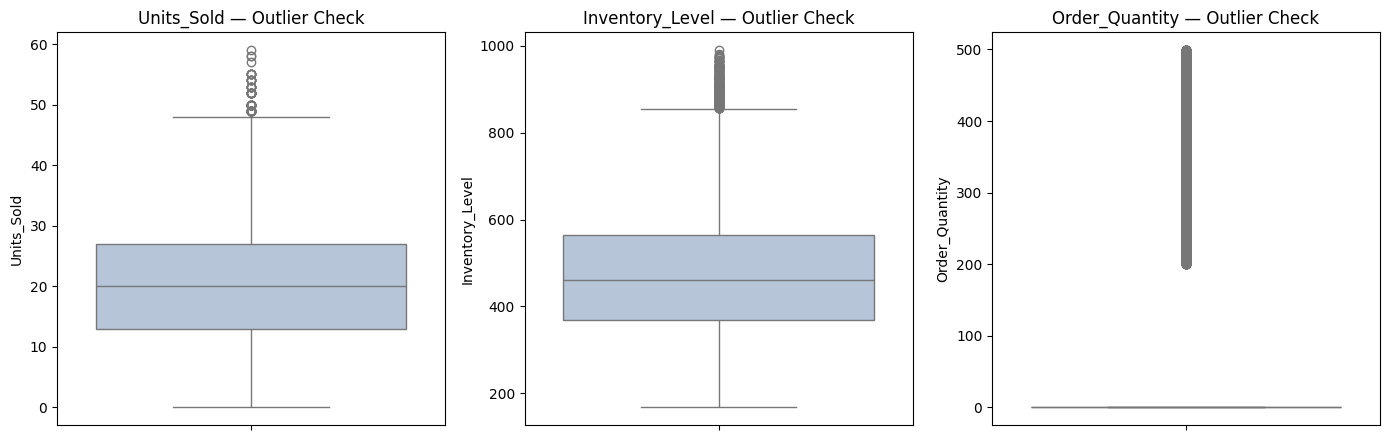

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, col in zip(axes, ["Units_Sold", "Inventory_Level", "Order_Quantity"]):
    sns.boxplot(y=df[col], ax=ax, color="lightsteelblue")
    ax.set_title(f"{col} — Outlier Check")
plt.tight_layout()
plt.savefig("figures/fig01_outlier_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
print(f"{'Column':<20}{'Outliers':>10}{'% of data':>12}")
for col in ["Units_Sold", "Inventory_Level", "Order_Quantity", "Supplier_Lead_Time_Days"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col:<20}{n_out:>10}{n_out/len(df)*100:>11.1f}%")

Column                Outliers   % of data
Units_Sold                 110        0.1%
Inventory_Level            199        0.2%
Order_Quantity            5027        5.5%
Supplier_Lead_Time_Days         0        0.0%


In [19]:
correlation_with_target = df["Demand_Forecast"].corr(df["Units_Sold"])
print(f"Correlation between Demand_Forecast and Units_Sold: {correlation_with_target:.4f}")

diff = df["Demand_Forecast"] - df["Units_Sold"]
print("\nDemand_Forecast minus Units_Sold (should be near-zero noise if it's a pre-existing forecast):")
print(diff.describe())

Correlation between Demand_Forecast and Units_Sold: 0.9493

Demand_Forecast minus Units_Sold (should be near-zero noise if it's a pre-existing forecast):
count    91250.000000
mean         0.027469
std          2.987263
min        -13.000000
25%         -1.990000
50%          0.010000
75%          2.030000
max         14.080000
dtype: float64


In [20]:
clean_df = df.copy()

clean_df["Date"] = pd.to_datetime(clean_df["Date"])

clean_df = clean_df.drop(columns=["Stockout_Flag"])

print("Date dtype after conversion:", clean_df["Date"].dtype)
print("Columns after cleaning:", clean_df.shape[1], "(dropped Stockout_Flag)")

Date dtype after conversion: datetime64[ns]
Columns after cleaning: 14 (dropped Stockout_Flag)


In [21]:
print("Remaining missing values:", clean_df.isnull().sum().sum())
print("Remaining duplicate rows:", clean_df.duplicated().sum())
print("Date column is now:", clean_df["Date"].dtype)
print("'Stockout_Flag' still present:", "Stockout_Flag" in clean_df.columns)

Remaining missing values: 0
Remaining duplicate rows: 0
Date column is now: datetime64[ns]
'Stockout_Flag' still present: False


In [22]:
clean_df["Month"] = clean_df["Date"].dt.month
clean_df["DayOfWeek"] = clean_df["Date"].dt.day_name()
clean_df["DayOfYear"] = clean_df["Date"].dt.dayofyear

clean_df[["Date", "Month", "DayOfWeek", "DayOfYear"]].head()

,Date,Month,DayOfWeek,DayOfYear
0,2024-01-01,1,Monday,1
1,2024-01-02,1,Tuesday,2
2,2024-01-03,1,Wednesday,3
3,2024-01-04,1,Thursday,4
4,2024-01-05,1,Friday,5


In [23]:
numeric_features = ["Inventory_Level", "Supplier_Lead_Time_Days", "Reorder_Point",
                    "Order_Quantity", "Unit_Cost", "Unit_Price", "Promotion_Flag"]
categorical_features = ["Month", "Region", "Warehouse_ID"]
target = "Units_Sold"

print("Numeric features:", numeric_features)
print("Categorical features (to be one-hot encoded):", categorical_features)
print("Target:", target)

Numeric features: ['Inventory_Level', 'Supplier_Lead_Time_Days', 'Reorder_Point', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Promotion_Flag']
Categorical features (to be one-hot encoded): ['Month', 'Region', 'Warehouse_ID']
Target: Units_Sold


In [24]:
model_df = clean_df.copy()
model_df["Month"] = model_df["Month"].astype(str)

encoded_categorical = pd.get_dummies(model_df[categorical_features], drop_first=True)

X = pd.concat([model_df[numeric_features], encoded_categorical], axis=1)
y = model_df[target]

print("Final feature matrix shape:", X.shape)
X.head()

Final feature matrix shape: (91250, 25)


,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Month_10,Month_11,Month_12,...,Month_7,Month_8,Month_9,Region_North,Region_South,Region_West,Warehouse_ID_WH_2,Warehouse_ID_WH_3,Warehouse_ID_WH_4,Warehouse_ID_WH_5
0,592,14,379,0,13.95,20.48,0,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,575,14,379,0,13.95,20.48,0,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,540,14,379,0,13.95,20.48,1,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,516,14,379,0,13.95,20.48,0,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,495,14,379,0,13.95,20.48,0,False,False,False,...,False,False,False,False,False,True,False,False,False,False


FileNotFoundError: [Errno 2] No such file or directory: 'figures/fig02_target_distribution.png'

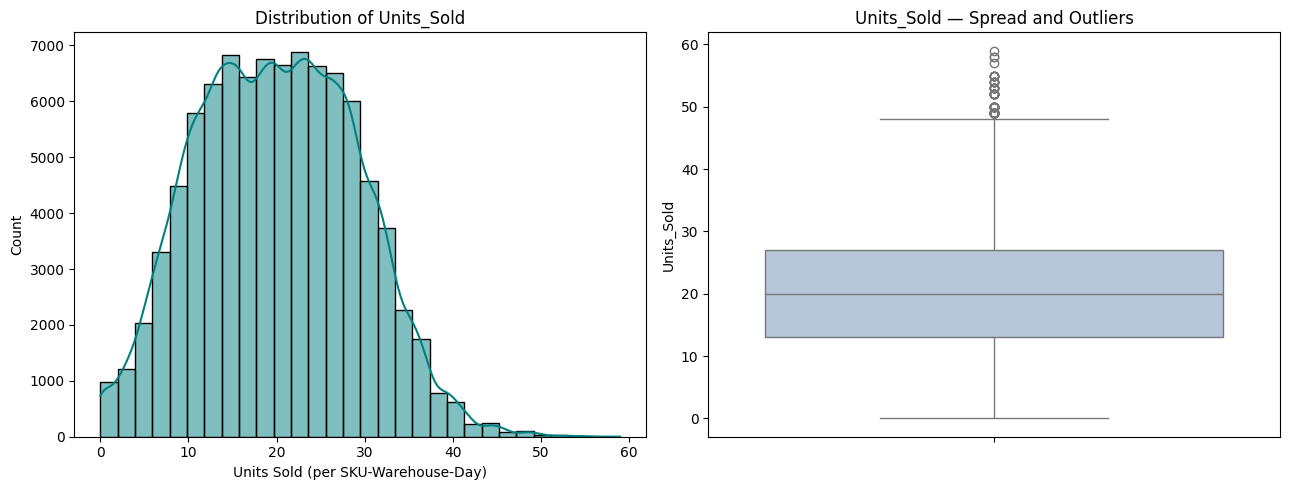

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(clean_df["Units_Sold"], bins=30, kde=True, color="teal", ax=axes[0])
axes[0].set_title("Distribution of Units_Sold")
axes[0].set_xlabel("Units Sold (per SKU-Warehouse-Day)")

sns.boxplot(y=clean_df["Units_Sold"], ax=axes[1], color="lightsteelblue")
axes[1].set_title("Units_Sold — Spread and Outliers")

plt.tight_layout()
plt.savefig("figures/fig02_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(clean_df["Units_Sold"].describe())
print("Skewness:", clean_df["Units_Sold"].skew().round(3))

FileNotFoundError: [Errno 2] No such file or directory: 'figures/fig03_predictor_distributions.png'

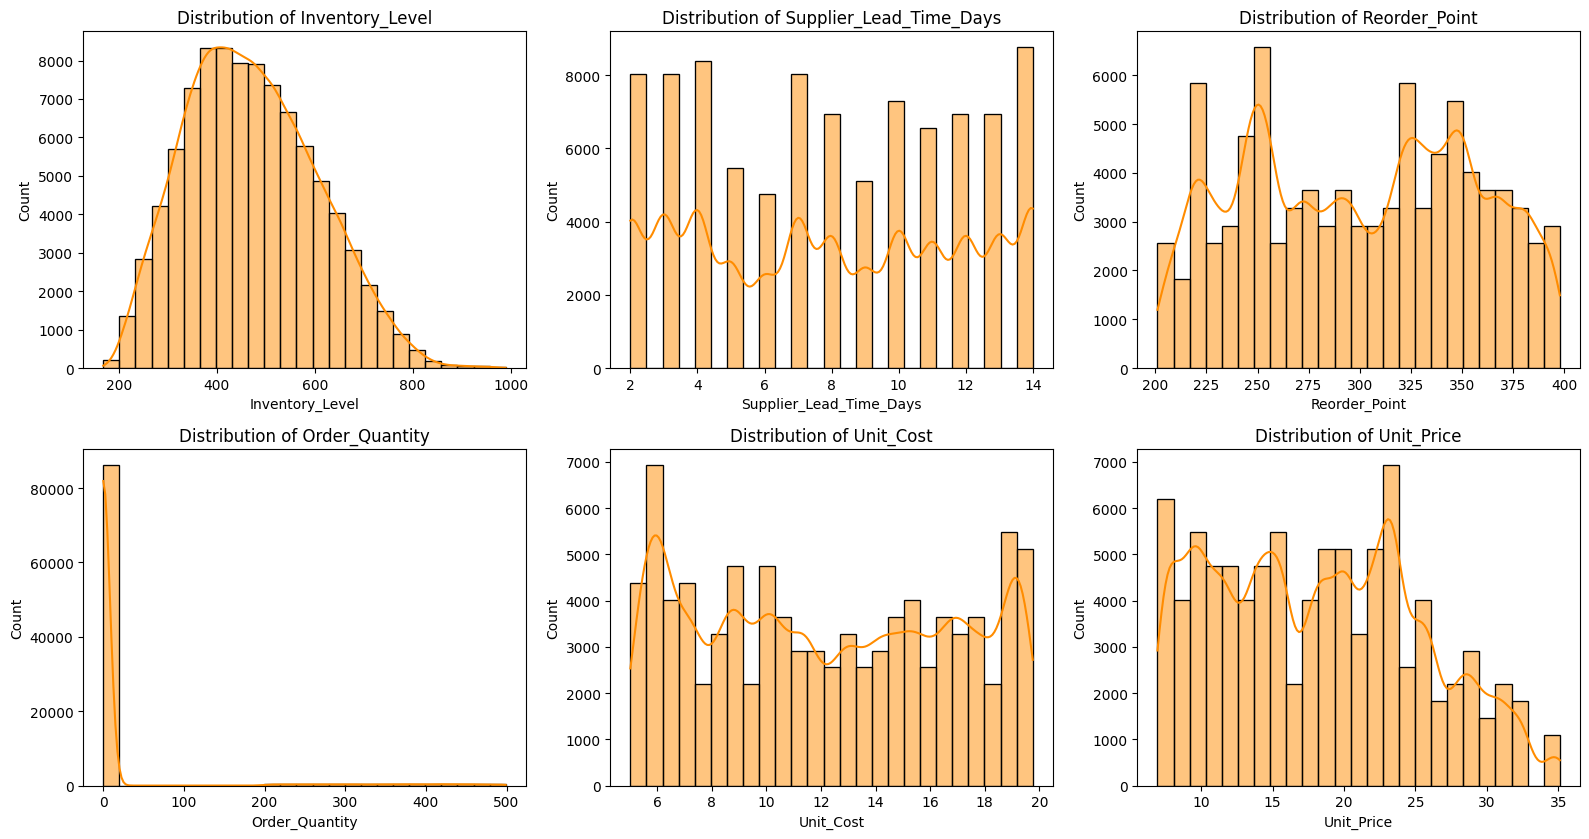

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
dist_cols = ["Inventory_Level", "Supplier_Lead_Time_Days", "Reorder_Point",
             "Order_Quantity", "Unit_Cost", "Unit_Price"]
for ax, col in zip(axes.flat, dist_cols):
    sns.histplot(clean_df[col], bins=25, kde=True, color="darkorange", ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("figures/fig03_predictor_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

Month
1     22.80
2     27.20
3     29.88
4     29.84
5     27.21
6     22.67
7     17.41
8     12.78
9     10.17
10    10.27
11    13.08
12    17.59
Name: Units_Sold, dtype: float64


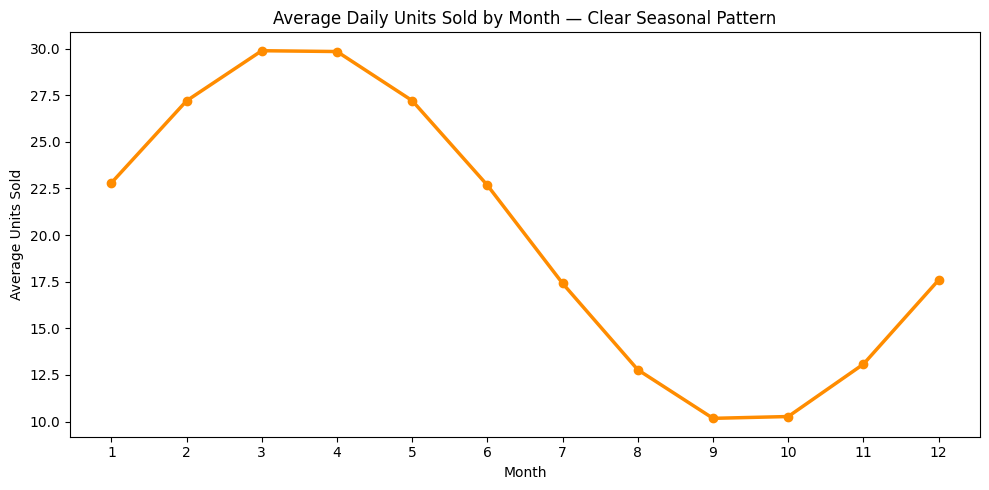

In [28]:
monthly_demand = clean_df.groupby("Month")["Units_Sold"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_demand.index, monthly_demand.values, marker="o", linewidth=2.5, color="darkorange")
ax.set_title("Average Daily Units Sold by Month — Clear Seasonal Pattern")
ax.set_xlabel("Month")
ax.set_ylabel("Average Units Sold")
ax.set_xticks(range(1, 13))
plt.tight_layout()


print(monthly_demand.round(2))

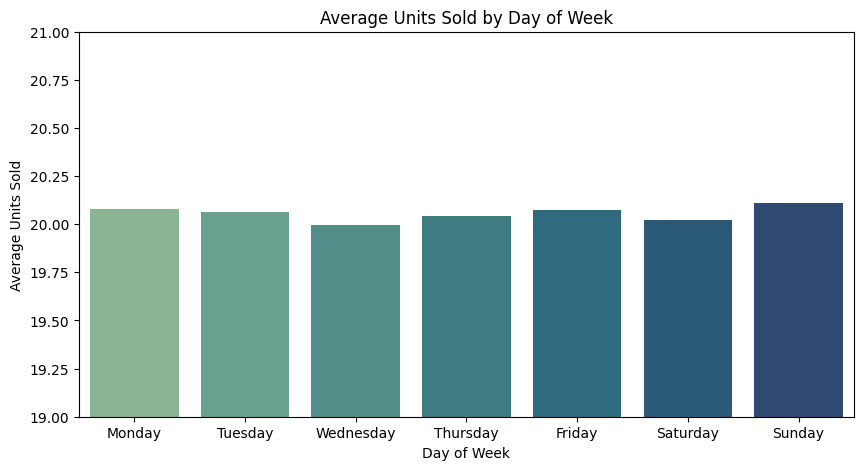

DayOfWeek
Monday       20.080
Tuesday      20.062
Wednesday    19.995
Thursday     20.040
Friday       20.075
Saturday     20.020
Sunday       20.109
Name: Units_Sold, dtype: float64


In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_demand = clean_df.groupby("DayOfWeek")["Units_Sold"].mean().reindex(day_order)
sns.barplot(x=dow_demand.index, y=dow_demand.values, hue=dow_demand.index,
            palette="crest", legend=False, ax=ax)
ax.set_title("Average Units Sold by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Units Sold")
ax.set_ylim(19, 21)
plt.show()

print(dow_demand.round(3))

FileNotFoundError: [Errno 2] No such file or directory: 'figures/fig06_groupwise_comparison.png'

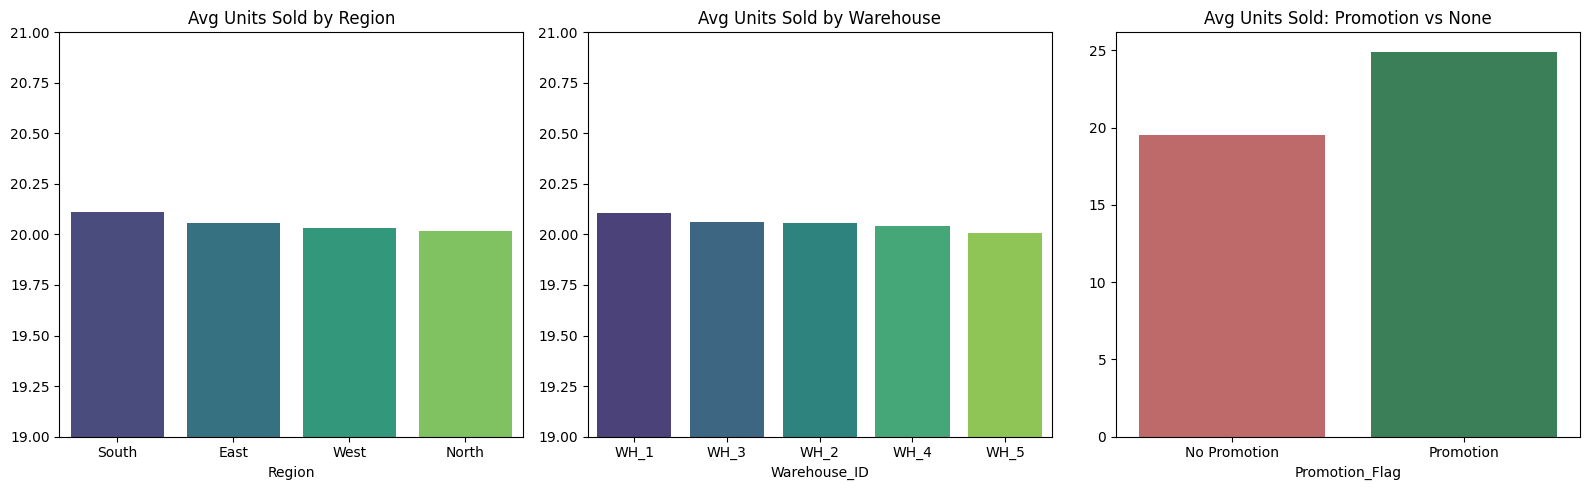

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

region_demand = clean_df.groupby("Region")["Units_Sold"].mean().sort_values(ascending=False)
sns.barplot(x=region_demand.index, y=region_demand.values, hue=region_demand.index,
            palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Avg Units Sold by Region")
axes[0].set_ylim(19, 21)

wh_demand = clean_df.groupby("Warehouse_ID")["Units_Sold"].mean().sort_values(ascending=False)
sns.barplot(x=wh_demand.index, y=wh_demand.values, hue=wh_demand.index,
            palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("Avg Units Sold by Warehouse")
axes[1].set_ylim(19, 21)

promo_demand = clean_df.groupby("Promotion_Flag")["Units_Sold"].mean()
sns.barplot(x=promo_demand.index.map({0: "No Promotion", 1: "Promotion"}), y=promo_demand.values,
            hue=promo_demand.index, palette=["indianred", "seagreen"], legend=False, ax=axes[2])
axes[2].set_title("Avg Units Sold: Promotion vs None")

plt.tight_layout()
plt.savefig("figures/fig06_groupwise_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("By Region:\n", region_demand.round(2), "\n")
print("By Warehouse:\n", wh_demand.round(2), "\n")
print("By Promotion:\n", promo_demand.round(2))

FileNotFoundError: [Errno 2] No such file or directory: 'figures/fig07_bivariate_scatter.png'

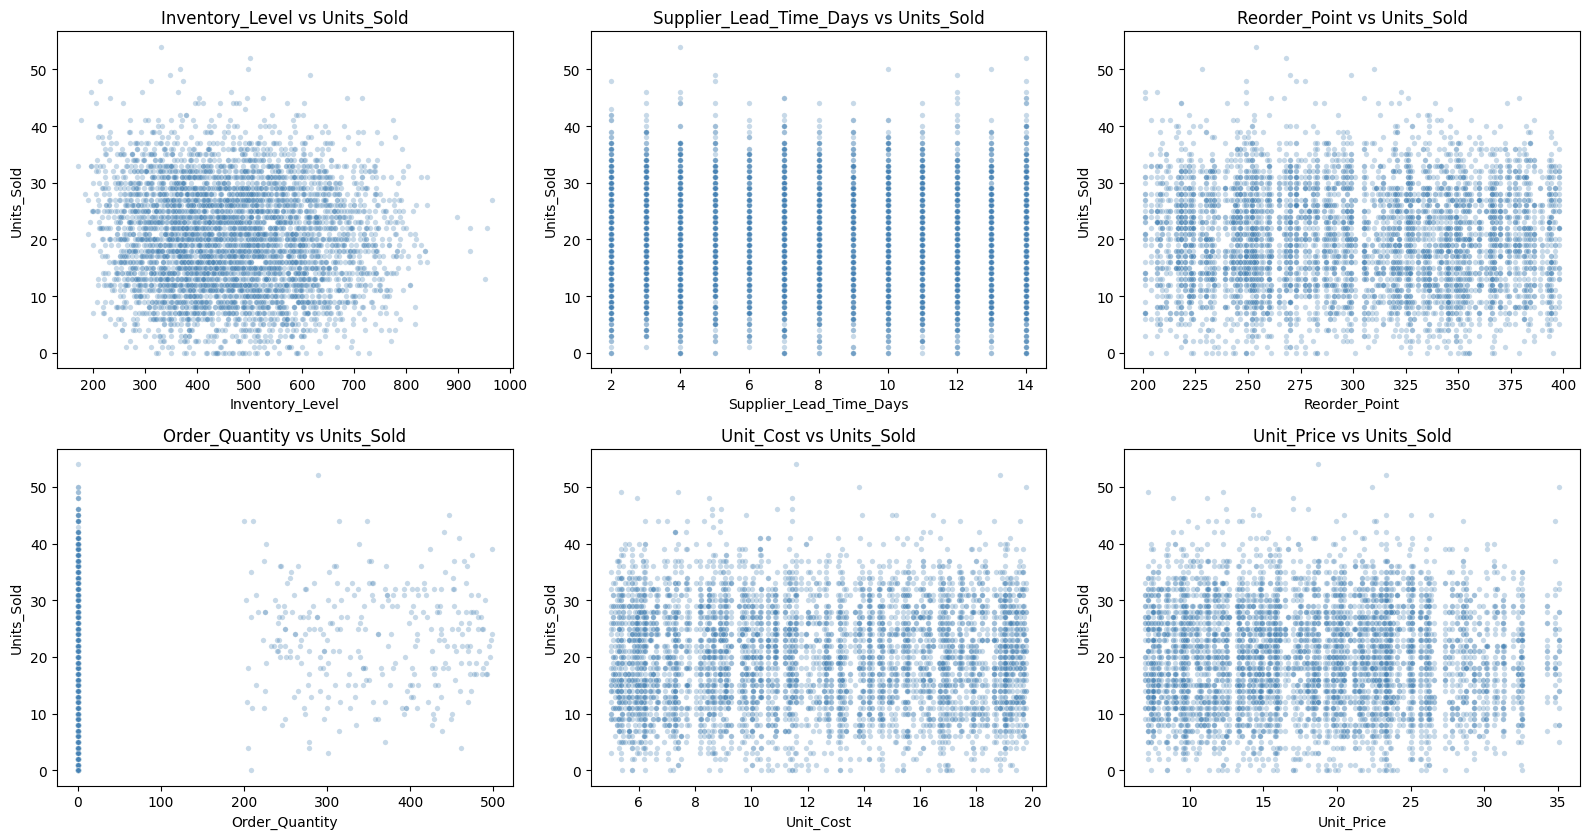

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
scatter_cols = ["Inventory_Level", "Supplier_Lead_Time_Days", "Reorder_Point",
                "Order_Quantity", "Unit_Cost", "Unit_Price"]
for ax, col in zip(axes.flat, scatter_cols):
    sns.scatterplot(data=clean_df.sample(5000, random_state=RANDOM_STATE), x=col, y="Units_Sold",
                     alpha=0.3, color="steelblue", ax=ax, s=15)
    ax.set_title(f"{col} vs Units_Sold")
plt.tight_layout()
plt.savefig("figures/fig07_bivariate_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

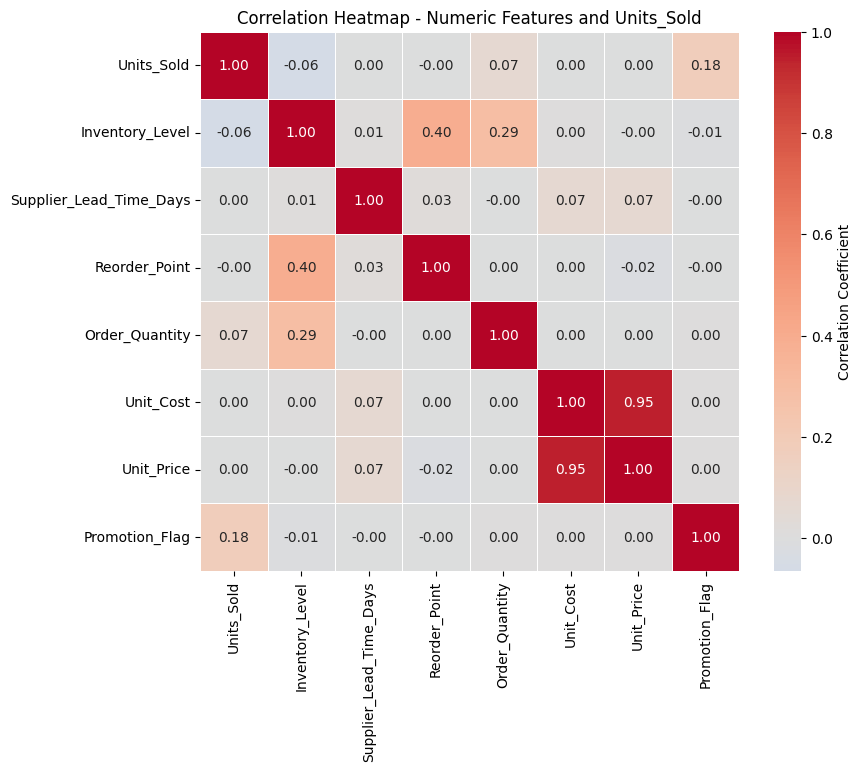

Correlation with Units_Sold, sorted by strength:
Promotion_Flag             0.180224
Order_Quantity             0.069328
Inventory_Level           -0.064285
Unit_Cost                  0.001669
Reorder_Point             -0.001630
Unit_Price                 0.001294
Supplier_Lead_Time_Days    0.000508
Name: Units_Sold, dtype: float64


In [34]:
corr_cols = ["Units_Sold", "Inventory_Level", "Supplier_Lead_Time_Days", "Reorder_Point",
             "Order_Quantity", "Unit_Cost", "Unit_Price", "Promotion_Flag"]
corr_matrix = clean_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"label": "Correlation Coefficient"}, ax=ax)
ax.set_title("Correlation Heatmap - Numeric Features and Units_Sold")
plt.show()

print("Correlation with Units_Sold, sorted by strength:")
print(corr_matrix["Units_Sold"].drop("Units_Sold").sort_values(key=abs, ascending=False))

In [35]:
stats_summary = clean_df[["Units_Sold", "Inventory_Level", "Order_Quantity", "Unit_Price"]].agg(
    ["mean", "median", "std", lambda s: s.quantile(0.75) - s.quantile(0.25)]
).T
stats_summary.columns = ["Mean", "Median", "Std Dev", "IQR"]
stats_summary.round(2)

,Mean,Median,Std Dev,IQR
Units_Sold,20.05,20.00,9.07,14.00
Inventory_Level,471.52,461.00,133.49,194.00
Order_Quantity,19.27,0.00,82.34,0.00
Unit_Price,18.26,18.18,7.12,11.39


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:     {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)")

train_idx = X_train.index
test_idx = X_test.index
print("\nMonths represented in training set:", sorted(model_df.loc[train_idx, 'Month'].unique()))
print("Months represented in test set:", sorted(model_df.loc[test_idx, 'Month'].unique()))

Training set: 73,000 rows (80.0%)
Test set:     18,250 rows (20.0%)

Months represented in training set: ['1', '10', '11', '12', '2', '3', '4', '5', '6', '7', '8', '9']
Months represented in test set: ['1', '10', '11', '12', '2', '3', '4', '5', '6', '7', '8', '9']


In [37]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

print("Model trained on", X_train.shape[0], "rows using", X_train.shape[1], "features.")

Model trained on 73000 rows using 25 features.


In [38]:
def regression_report(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE  : {mae:.3f} units")
    print(f"MSE  : {mse:.3f}")
    print(f"RMSE : {rmse:.3f} units")
    print(f"R2   : {r2:.4f}")
    print()
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

train_metrics = regression_report(y_train, y_train_pred, "Training Set")
test_metrics = regression_report(y_test, y_test_pred, "Test Set")

--- Training Set ---
MAE  : 4.218 units
MSE  : 28.081
RMSE : 5.299 units
R2   : 0.6585

--- Test Set ---
MAE  : 4.199 units
MSE  : 27.809
RMSE : 5.273 units
R2   : 0.6619



In [39]:
benchmark_slice = model_df.loc[test_idx]
benchmark_mae = mean_absolute_error(benchmark_slice["Units_Sold"], benchmark_slice["Demand_Forecast"])
benchmark_rmse = np.sqrt(mean_squared_error(benchmark_slice["Units_Sold"], benchmark_slice["Demand_Forecast"]))
benchmark_r2 = r2_score(benchmark_slice["Units_Sold"], benchmark_slice["Demand_Forecast"])

comparison = pd.DataFrame({
    "Existing Demand_Forecast (benchmark)": [benchmark_mae, benchmark_rmse, benchmark_r2],
    "Our Linear Regression Model": [test_metrics["MAE"], test_metrics["RMSE"], test_metrics["R2"]]
}, index=["MAE", "RMSE", "R2"]).round(3)

comparison

,Existing Demand_Forecast (benchmark),Our Linear Regression Model
MAE,2.363,4.199
RMSE,2.979,5.273
R2,0.892,0.662


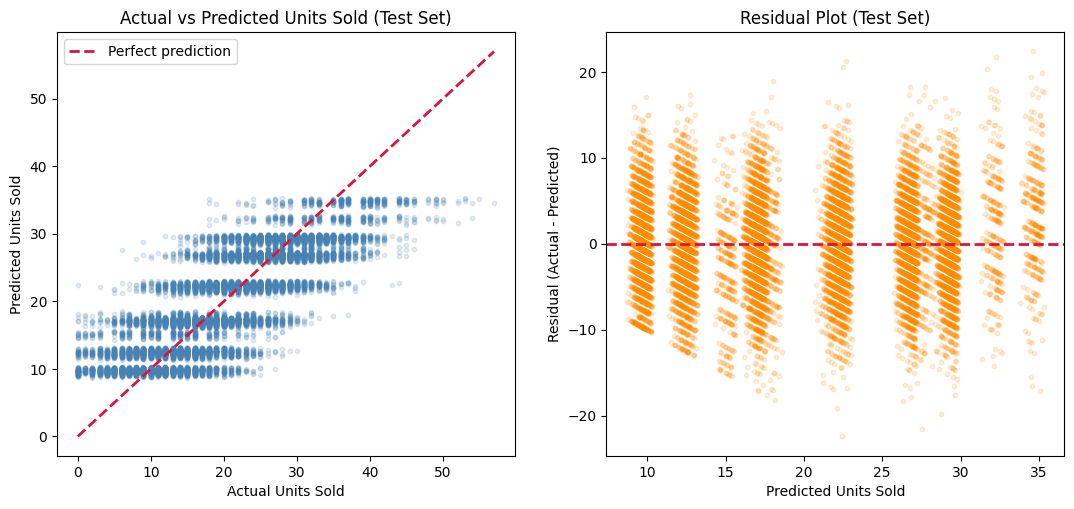

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].scatter(y_test, y_test_pred, alpha=0.15, color="steelblue", s=10)
lims = [0, max(y_test.max(), y_test_pred.max())]
axes[0].plot(lims, lims, color="crimson", linestyle="--", linewidth=2, label="Perfect prediction")
axes[0].set_title("Actual vs Predicted Units Sold (Test Set)")
axes[0].set_xlabel("Actual Units Sold")
axes[0].set_ylabel("Predicted Units Sold")
axes[0].legend()

residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.15, color="darkorange", s=10)
axes[1].axhline(0, color="crimson", linestyle="--", linewidth=2)
axes[1].set_title("Residual Plot (Test Set)")
axes[1].set_xlabel("Predicted Units Sold")
axes[1].set_ylabel("Residual (Actual - Predicted)")
plt.show()

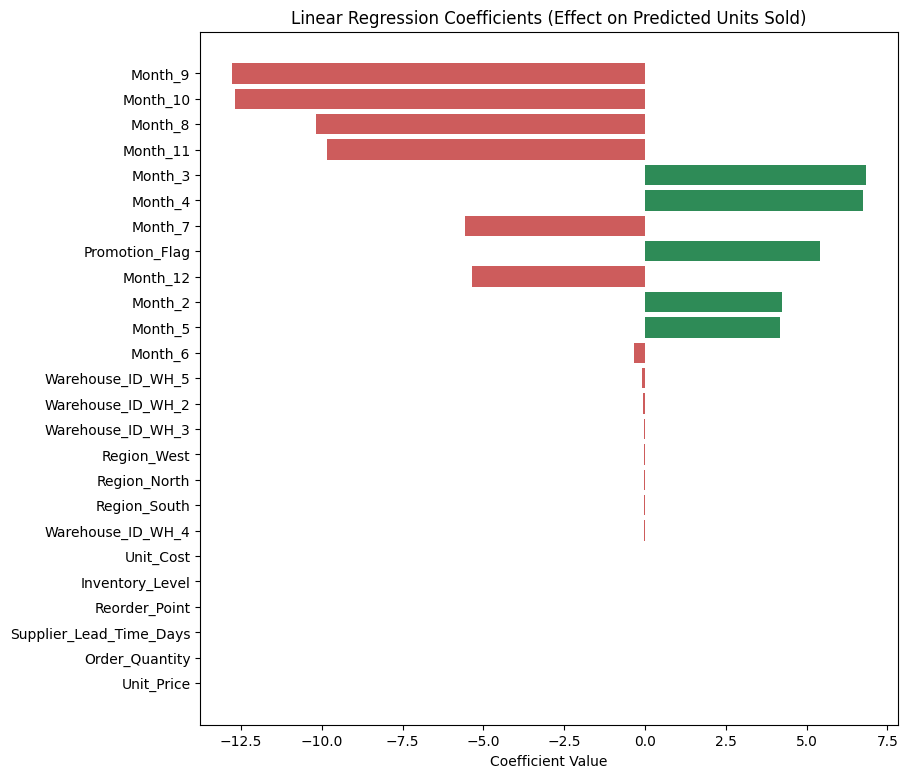

,Feature,Coefficient
17,Month_9,-12.784
7,Month_10,-12.704
16,Month_8,-10.176
8,Month_11,-9.836
11,Month_3,6.837
12,Month_4,6.751
15,Month_7,-5.563
6,Promotion_Flag,5.402
9,Month_12,-5.343
10,Month_2,4.251


In [42]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lin_reg.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 9))
colors = ["seagreen" if c > 0 else "indianred" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.set_title("Linear Regression Coefficients (Effect on Predicted Units Sold)")
ax.set_xlabel("Coefficient Value")
ax.invert_yaxis()

plt.show()

coef_df.round(3)

In [43]:
comparison_table = pd.DataFrame({"Train": train_metrics, "Test": test_metrics}).round(3)
comparison_table

,Train,Test
MAE,4.218,4.199
MSE,28.081,27.809
RMSE,5.299,5.273
R2,0.659,0.662


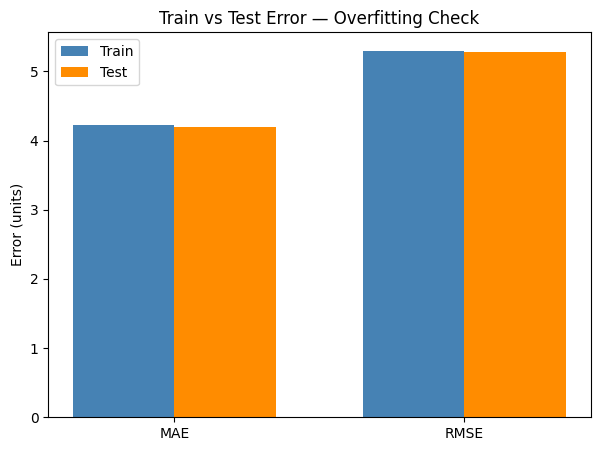

In [44]:
fig, ax = plt.subplots(figsize=(7, 5))
metrics_to_plot = ["MAE", "RMSE"]
x = np.arange(len(metrics_to_plot))
width = 0.35

train_vals = [train_metrics[m] for m in metrics_to_plot]
test_vals = [test_metrics[m] for m in metrics_to_plot]

ax.bar(x - width/2, train_vals, width, label="Train", color="steelblue")
ax.bar(x + width/2, test_vals, width, label="Test", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_title("Train vs Test Error — Overfitting Check")
ax.set_ylabel("Error (units)")
ax.legend()

plt.show()